# 01_EDA_image.ipynb
## Phân tích thống kê tập dữ liệu ảnh số (Phần 1)

Mục tiêu: Phân tích thống kê mô tả toàn diện tập dữ liệu ảnh trước khi tiền xử lý.

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from collections import Counter
import cv2

# Tên các lớp
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Đường dẫn
DATA_PATH = '../data/raw/image-data/data_batch_1'

# Tải ảnh từ pickle file
print("Đang tải ảnh từ data_batch_1...")
with open(DATA_PATH, 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

# Chuyển đổi dữ liệu: (N, 3072) -> (N, 32, 32, 3)
images = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
labels = np.array(batch[b'labels'])

print(f"Tổng: {len(images)} ảnh, kích thước: {images.shape}")
print(f"Số lớp: {len(np.unique(labels))}")

# Đếm số lượng mỗi lớp
label_counts = Counter(labels)
print("\nSố lượng ảnh mỗi lớp:")
for class_idx, class_name in enumerate(class_names):
    print(f"  {class_name}: {label_counts[class_idx]} ảnh")

Đang tải ảnh từ data_batch_1...
Tổng: 10000 ảnh, kích thước: (10000, 32, 32, 3)
Số lớp: 10

Số lượng ảnh mỗi lớp:
  airplane: 1005 ảnh
  automobile: 974 ảnh
  bird: 1032 ảnh
  cat: 1016 ảnh
  deer: 999 ảnh
  dog: 937 ảnh
  frog: 1030 ảnh
  horse: 1001 ảnh
  ship: 1025 ảnh
  truck: 981 ảnh


## 2.1.2a Phân phối giá trị pixel theo từng kênh màu (Histogram + KDE)

Tính và trực quan hóa phân phối giá trị pixel theo từng kênh màu (R, G, B).

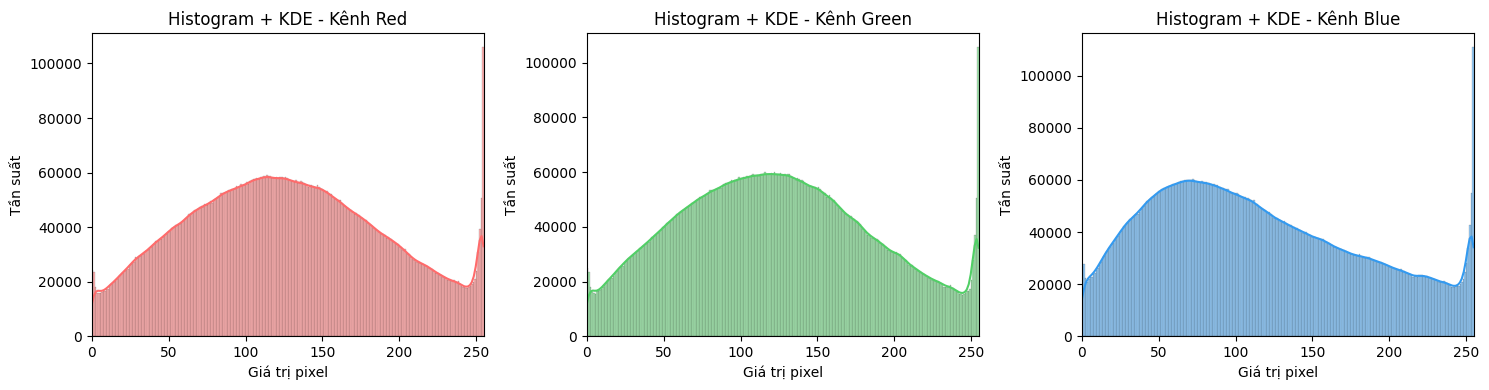


Thống kê kênh màu:
Red: Mean=125.83, Std=63.14, Min=0, Max=255
Green: Mean=123.26, Std=62.37, Min=0, Max=255
Blue: Mean=114.03, Std=66.97, Min=0, Max=255


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = ['Red', 'Green', 'Blue']
colors = ['#FF6B6B', '#51CF66', '#339AF0']

for i, ax in enumerate(axes):
    channel_data = images[:, :, :, i].flatten()
    sns.histplot(channel_data, kde=True, ax=ax, color=colors[i], bins=256)
    ax.set_title(f'Histogram + KDE - Kênh {channel_names[i]}')
    ax.set_xlabel('Giá trị pixel')
    ax.set_ylabel('Tần suất')
    ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()

print(f"\nThống kê kênh màu:")
for i, name in enumerate(channel_names):
    channel = images[:, :, :, i]
    print(f"{name}: Mean={np.mean(channel):.2f}, Std={np.std(channel):.2f}, Min={np.min(channel)}, Max={np.max(channel)}")

## 2.1.2b Phân tích mất cân bằng lớp (Class Imbalance)

Tính tỷ lệ mỗi lớp, kiểm tra xem có lớp nào chiếm tỷ lệ vượt mức 3× so với lớp ít nhất không.

In [3]:
label_counts = Counter(labels)
class_ratios = {class_names[k]: v / len(labels) * 100 for k, v in label_counts.items()}

print("\nTỷ lệ mỗi lớp:")
for name, ratio in class_ratios.items():
    print(f"  {name}: {ratio:.2f}%")

max_ratio = max(class_ratios.values())
min_ratio = min(class_ratios.values())
is_imbalanced = max_ratio > 3 * min_ratio

print(f"\nTỷ lệ lớn nhất: {max_ratio:.2f}%")
print(f"Tỷ lệ nhỏ nhất: {min_ratio:.2f}%")
print(f"Có lớp nào vượt 3× lớp ít nhất? {is_imbalanced}")


Tỷ lệ mỗi lớp:
  frog: 10.30%
  truck: 9.81%
  deer: 9.99%
  automobile: 9.74%
  bird: 10.32%
  horse: 10.01%
  ship: 10.25%
  cat: 10.16%
  dog: 9.37%
  airplane: 10.05%

Tỷ lệ lớn nhất: 10.32%
Tỷ lệ nhỏ nhất: 9.37%
Có lớp nào vượt 3× lớp ít nhất? False


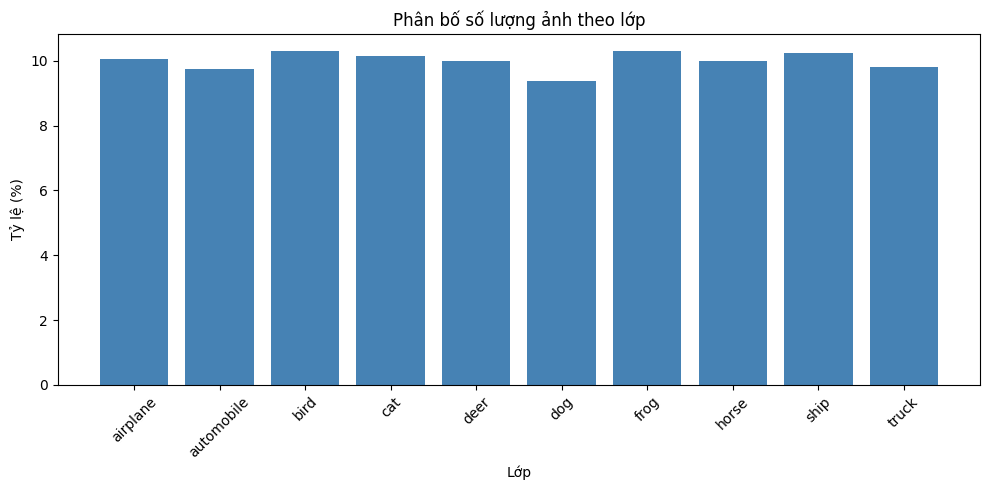

In [4]:
plt.figure(figsize=(10, 5))
plt.bar(class_names, [class_ratios[name] for name in class_names], color='steelblue')
plt.xlabel('Lớp')
plt.ylabel('Tỷ lệ (%)')
plt.title('Phân bố số lượng ảnh theo lớp')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.1.2c Phát hiện ảnh trùng lặp bằng Perceptual Hash (pHash)

Sử dụng perceptual hash (pHash) dựa trên DCT (Discrete Cosine Transform) để phát hiện ảnh trùng lặp hoặc gần trùng lặp.

Tổng số ảnh: 10000
Số ảnh trùng lặp: 2
Tỷ lệ trùng lặp: 0.0200%

Ví dụ trùng lặp (ảnh 9275 trùng với ảnh 4875):


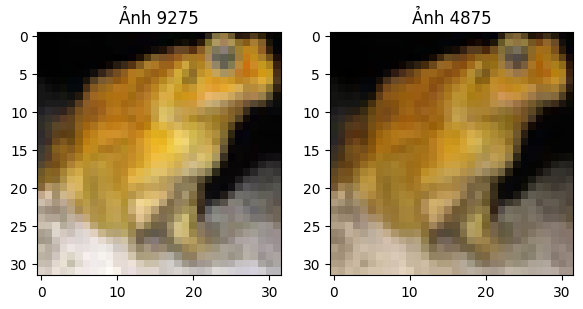

In [5]:
def compute_phash(img_array, hash_size=8):
    """
    Tính perceptual hash (pHash) cho ảnh sử dụng DCT (Discrete Cosine Transform).
    pHash sử dụng DCT để tạo hash perceptual.
    """
    from scipy.fftpack import dct
    img = Image.fromarray(img_array)
    img = img.resize((hash_size, hash_size), Image.LANCZOS)
    img = img.convert('L')
    pixels = np.array(img, dtype=np.float32)
    dct_coeffs = dct(dct(pixels, axis=0, type=2, norm='ortho'), axis=1, type=2, norm='ortho')
    dct_low = dct_coeffs[:hash_size, :hash_size]
    avg = np.mean(dct_low[1:])
    return ''.join(['1' if c >= avg else '0' for c in dct_low.flatten()])

hash_dict = {}
duplicates = []

for i, img_array in enumerate(images):
    img_hash = compute_phash(img_array)
    if img_hash in hash_dict:
        duplicates.append((i, hash_dict[img_hash]))
    else:
        hash_dict[img_hash] = i

dup_rate = len(duplicates) / len(images) * 100

print(f"Tổng số ảnh: {len(images)}")
print(f"Số ảnh trùng lặp: {len(duplicates)}")
print(f"Tỷ lệ trùng lặp: {dup_rate:.4f}%")

if len(duplicates) > 0:
    print(f"\nVí dụ trùng lặp (ảnh {duplicates[0][0]} trùng với ảnh {duplicates[0][1]}):")
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(images[duplicates[0][0]])
    axes[0].set_title(f'Ảnh {duplicates[0][0]}')
    axes[1].imshow(images[duplicates[0][1]])
    axes[1].set_title(f'Ảnh {duplicates[0][1]}')
    plt.tight_layout()
    plt.show()
else:
    print("\nKhông phát hiện ảnh trùng lặp trong tập dữ liệu.")

## 2.1.2d Phân tích độ tương phản và độ sáng (Mean Intensity + Boxplot)

Tính mean intensity và standard deviation theo lớp, thể hiện qua boxplot phân lớp.

In [6]:
mean_intensities = []
std_intensities = []

for i in range(10):
    mask = labels == i
    mean_int = np.mean(images[mask])
    std_int = np.std(images[mask])
    mean_intensities.append(mean_int)
    std_intensities.append(std_int)
    print(f"{class_names[i]}: Mean={mean_int:.2f}, Std={std_int:.2f}")

airplane: Mean=143.37, Std=65.27
automobile: Mean=116.88, Std=69.22
bird: Mean=119.54, Std=60.07
cat: Mean=116.17, Std=65.09
deer: Mean=111.86, Std=55.01
dog: Mean=117.25, Std=64.11
frog: Mean=105.99, Std=58.38
horse: Mean=119.41, Std=63.97
ship: Mean=133.81, Std=63.34
truck: Mean=126.01, Std=70.11


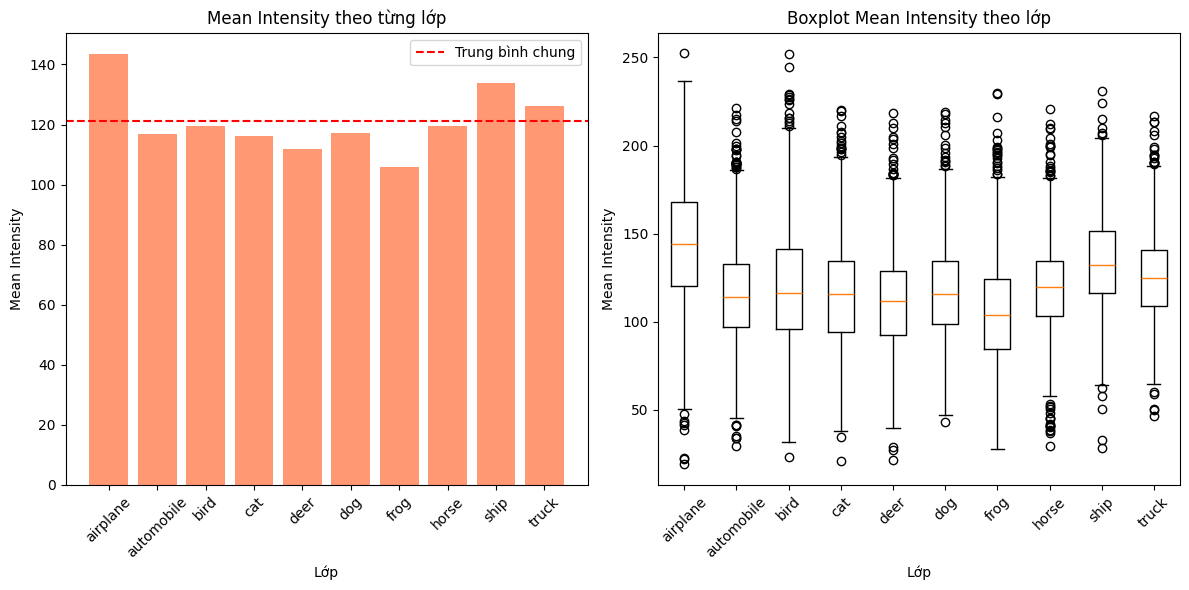


Mean intensity trung bình: 121.03
Std trung bình: 63.46


In [7]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(class_names, mean_intensities, color='coral', alpha=0.8)
plt.xlabel('Lớp')
plt.ylabel('Mean Intensity')
plt.title('Mean Intensity theo từng lớp')
plt.xticks(rotation=45)
plt.axhline(y=np.mean(mean_intensities), color='red', linestyle='--', label='Trung bình chung')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([images[labels == i].mean(axis=(1,2,3)) for i in range(10)], tick_labels=class_names)
plt.xlabel('Lớp')
plt.ylabel('Mean Intensity')
plt.title('Boxplot Mean Intensity theo lớp')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"\nMean intensity trung bình: {np.mean(mean_intensities):.2f}")
print(f"Std trung bình: {np.mean(std_intensities):.2f}")